In [100]:
import os
import glob
import json
import pickle
import datetime
import itertools
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt

import networkx as nx

import dcor
import scipy as sp

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [101]:
# Vectorized euler intergration implementation

def plasticity_1(uEpochs, sigma_arr, nNodes, **opts):
    newSigma_arr = deepcopy(sigma_arr)
    dcorrepoch = np.zeros_like(sigma_arr)

    ueSource = uEpochs[0, :]
    uiSource = uEpochs[1, :]

    for n in range(1, nNodes):
        ueTarget = uEpochs[2 * n, :]
        corre = dcor.distance_correlation(ueSource, ueTarget)
        corre = np.clip(corre, 0, 1)
        newSigma_arr[2 * n] +=  opts.get('dt') * opts.get('epis_e') * (corre - opts.get('r0'))

        uiTarget = uEpochs[2 * n + 1, :]
        corri = dcor.distance_correlation(uiSource, uiTarget)
        corri = np.clip(corri, 0, 1)
        newSigma_arr[2 * n + 1] +=  opts.get('dt') * opts.get('epis_i') * (corri - opts.get('r0'))

        dcorrepoch[2 * n] = corre
        dcorrepoch[2 * n + 1] = corri

    return newSigma_arr, dcorrepoch

def euler_intergrate(u, init_point, modNodes, laps_window,  **opts):
    # common parameters
    beta = opts.get('beta')
    gamma = opts.get('gamma')
    theta = opts.get('theta')

    nTrials, N = init_point.shape
    nNodes = N // 2

    sigmaArr = np.zeros((nTrials, 2 * nNodes, opts.get('T')))
    dcorrArr = np.zeros((nTrials, 2 * nNodes, opts.get('T')))

    for q in range(nTrials):
        u[q, :, 0] = init_point[q, :]       # initializing membrane potentials
        sigmaArr[q, :, 0] = opts.get('sigma')

        for t in range(opts.get('T') - 1):
            Fvect = np.zeros((2 * nNodes, 1))
            Imod = np.zeros((2 * nNodes, 1))

            for n in range(nNodes):
                Fvect[2 * n] = F(u[q, 2 * n, t], beta, theta, gamma, sigmaArr[q, 2 * n, t])
                Fvect[2 * n + 1] = F(u[q, 2 * n + 1, t], beta, theta, gamma, sigmaArr[q, 2 * n + 1, t])

                Imod[2 * n] = opts.get('i_mod') if n in modNodes else 0

            uVect = -u[q, :, t].reshape(-1, 1) + opts.get('W') @ Fvect + opts.get('Kglob') * opts.get('Abar') @ u[q, :, t].reshape(-1, 1) + opts.get('i_bias') + Imod
            uVect = opts.get('dt') * opts.get('Tau') @ uVect
            u[q, :, t + 1] = u[q, :, t] + uVect.flatten()           # updating membrane potentials
            
            # heterogeneity plasticity

            if t < laps_window:
                sigmaArr[q, :, t + 1] = opts.get('sigma')
            else:
                sigmaArr[q, :, t + 1], dcorrArr[q, :, t] = plasticity_1(uEpochs=u[q, :, t - laps_window : t], sigma_arr=sigmaArr[q, :, t], nNodes=nNodes, **opts)
    return u, sigmaArr, dcorrArr

In [109]:
# read parameters from a json file
with open('./params.json', 'r+') as f:
    params = json.load(f)

# setting grid parameters
minval = -5 / params['gamma']
maxval = 5 / params['gamma']
grid_res = 100
nTrials = 1

params['N'] = nNodes = 10    # Network size

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)

t_start = 1000
t_end = T

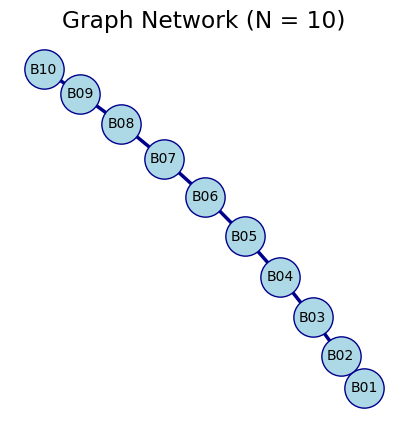

In [110]:
# Creating connectivity matrix (Adjacency Matrix)

## (1) Directional coupling

A = np.zeros((nNodes, nNodes))

for n in range(1, nNodes):
    A[n, n - 1] = 1

Dnet= np.zeros((nNodes, 2 * nNodes))

for n in range(nNodes):
    Dnet[n, 2 * n : 2 * n + 2] = np.array([1, 0])

params['Abar'] = Abar = (Dnet.T @ A) @ Dnet

G = nx.from_numpy_array(A, parallel_edges=False)
plot_weighted_graph(G = G, N = nNodes, ifSave = False, savePath='', figsize = (5, 5))

In [111]:
tau = np.diag(np.array([1 / params['tau_e'], 1 / params['tau_i']]))
params['Tau'] = Tau = np.kron(np.eye(nNodes), tau)

w = np.array([[params['wee'], params['wie']], [params['wei'], params['wii']]])
params['W'] = W = np.kron(np.eye(nNodes), w)

ibias = np.array([params['i_ebias'], params['i_ibias']])
params['i_bias'] = i_bias = np.repeat(ibias[np.newaxis,...], nNodes, axis=0).flatten().reshape(-1, 1)

In [120]:
# Setting variables

params['Kglob'] = 0.8
params['i_mod'] = 0.5 / params['gamma']

sigma = np.ones(2 * nNodes) * 2.5

# setting the source heterogeneity values
sigma[0] = 2.5
sigma[1] = 4.4

params['sigma'] = sigma

# setting correlation target and learning rates
params['r0'] = 0.01
params['epis_i'] = params['epis_e'] = 0.028

In [121]:
# Initialization
random.seed(0)
xInit = np.random.uniform(minval, maxval, (nTrials, 2 * nNodes))

In [122]:
lapsWindow = 250

u = np.zeros((nTrials, 2 * nNodes, T))
u, sig_plasticity, dcorrelation = euler_intergrate(u, xInit, modNodes = [0], laps_window=lapsWindow, **params)

(0.0, 9000.0)

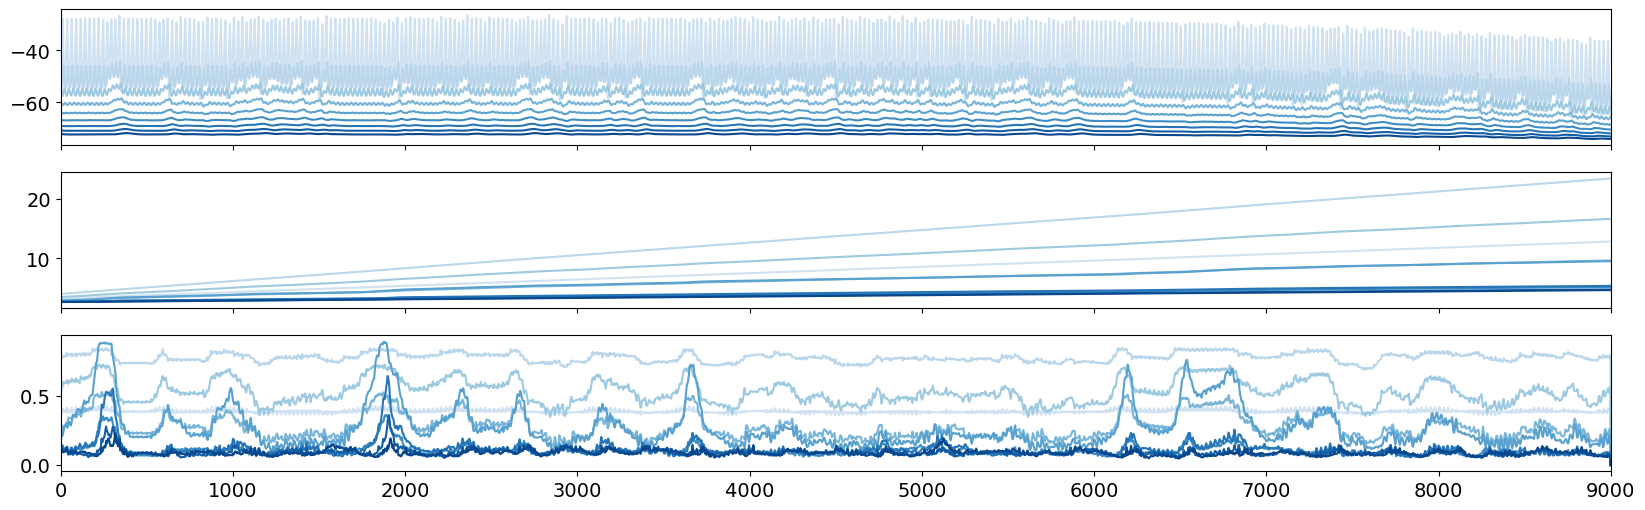

In [123]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(20, 6))
axs[0].set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, nNodes))))
axs[1].set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, nNodes))))
axs[2].set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, nNodes))))


for n in range(1, nNodes):
    axs[0].plot(time_[:-t_start], u[0, 2 * n, t_start :])
    axs[1].plot(time_[:-t_start], sig_plasticity[0, 2 * n, t_start :])
    axs[2].plot(time_[:-t_start], dcorrelation[0, 2 * n, t_start :])

axs[0].set_xlim(0, T - t_start)

